# 03 · Dataset comparison **A vs B** · DECIDE

**Owner:** Jaime · **Status:** sandbox · **Reading order:** after `00`–`02` · **Loader:** [`datasets.py`](datasets.py)

The team must pick **one** dataset for the working-memory project. This notebook puts the two finalists on
**one shared loader** (`datasets.py`, same output schema for both) and lays the evidence side by side:
subject counts, signal shapes, the prediction target, and an example functional-connectivity reconfiguration
map. It **equips** the decision — it does not make it unilaterally; target, FC estimation and prediction stay
team decisions (§6).

## 0 · Provenance

NMA-curated subset of the **Human Connectome Project** (HCP); use requires accepting the
[HCP Data Use Terms](https://www.humanconnectome.org/study/hcp-young-adult/document/wu-minn-hcp-consortium-open-access-data-use-terms).
Raw data under `data/`, **gitignored**.

| Finalist | Official loader | Local folders |
|---|---|---|
| **A** — 100 subj, task + behaviour | [`load_hcp_task_with_behaviour`](https://github.com/NeuromatchAcademy/course-content/blob/v3.0.2/projects/fMRI/load_hcp_task_with_behaviour.ipynb) | `data/A_load_hcp_task_with_behaviour/hcp_task/` |
| **B** — 339 subj, + resting-state | [`load_hcp`](https://github.com/NeuromatchAcademy/course-content/blob/v3.0.2/projects/fMRI/load_hcp.ipynb) | `data/B_load_hcp/` (`hcp_task_339/`, `hcp_rest/`, `hcp/`) |

## Setup

In [1]:
from pathlib import Path
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
JAIME = cwd if (cwd / "datasets.py").exists() else cwd / "sandbox" / "jaime"
ROOT = JAIME.parents[1]
sys.path.insert(0, str(JAIME))
import datasets as ds, preprocessing as pp, evaluation as ev

DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
C_A, C_B = "#3b6fb0", "#c1652a"                       # A = blue, B = orange, threaded throughout

A, B = ds.spec_a(DATA), ds.spec_b(DATA)
print("data dir:", DATA)
print("A:", A.name)
print("B:", B.name)

data dir: /Users/jaimepm/Library/Mobile Documents/com~apple~CloudDocs/Wiki/Life Long Learning/NeuroAcademy/project/fmri/the-gammas/data
A: Finalist A (100 subj, task-only)
B: Finalist B (339 subj, +resting-state)


---
## 1 · One loader, two datasets

`datasets.py` (config + I/O), `preprocessing.py` (transforms) and `evaluation.py` (split + QC) put both **A** and **B** behind a
common interface, so both datasets return the *same* objects:

`load_subjects` · `condition_timeseries` · `behaviour_table` · `region_table` · `validate_dataset`

**B specifics resolved inside the loader** (verified against the official `EXPERIMENTS['WM']['runs'] == [7, 8]`): WM runs are
`bold7` (**RL**) and `bold8` (**LR**) — the reverse run order of A, each segmented with its own EVs; behaviour
comes from the consolidated `wm.csv`; subjects **81, 143, 329** lack 2-back and are dropped (339 → 336).

In [2]:
rows = []
for spec in (A, B):
    subs = ds.load_subjects(spec)                              # analytic cohort (real IDs for A are NOT printed)
    m0 = pp.condition_timeseries(spec, subs[0], "0back")
    m2 = pp.condition_timeseries(spec, subs[0], "2back")
    rows.append({"dataset": spec.kind, "analytic subjects": len(subs),
                 "0-back signal (ROI×frames)": str(m0.shape),
                 "2-back signal (ROI×frames)": str(m2.shape)})
pd.DataFrame(rows).set_index("dataset")

,analytic subjects,0-back signal (ROI×frames),2-back signal (ROI×frames)
dataset,,,
A,100,"(360, 312)","(360, 312)"
B,336,"(360, 312)","(360, 312)"


## 2 · Aggregate QC, side by side — the decision evidence

`validate_dataset` probes a representative subject and reports counts, shapes and behavioural spread. **No
subject identifiers are returned.** This single table is the objective basis for the A/B choice.

In [3]:
qc = pd.DataFrame({"A": ev.validate_dataset(A), "B": ev.validate_dataset(B)})
qc

,A,B
dataset,"Finalist A (100 subj, task-only)","Finalist B (339 subj, +resting-state)"
n_subjects_total,100,339
n_subjects_analytic,100,336
wm_run_shape,"(360, 405)","(360, 405)"
frames_0back_per_run,156,156
frames_2back_per_run,156,156
frames_0back_concat,312,312
frames_2back_concat,312,312
cond_overlap,0,0
n_parcels,360,360


## 3 · The prediction target — `acc_2bk`

Both datasets yield a well-spread 2-back accuracy with a **comparable mean** (~0.84–0.85). B simply provides
**3.4× the subjects** at the same target definition (mean over 4 categories × 2 runs).

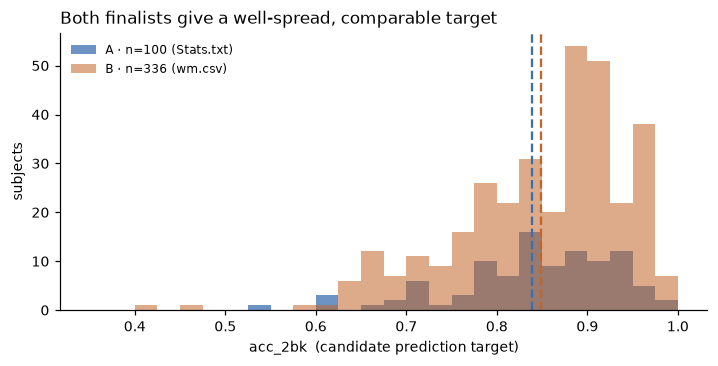

,A,B
count,100.000,336.000
mean,0.839,0.849
std,0.091,0.094
min,0.538,0.406
25%,0.788,0.797
50%,0.844,0.875
75%,0.912,0.922
max,0.988,1.000


In [4]:
beh_A, beh_B = pp.behaviour_table(A), pp.behaviour_table(B)
acc_A, acc_B = beh_A["acc_2bk"].dropna(), beh_B["acc_2bk"].dropna()

fig, ax = plt.subplots(figsize=(6.6, 3.4))
bins = np.linspace(0.35, 1.0, 27)
ax.hist(acc_A, bins=bins, color=C_A, alpha=0.75, label=f"A · n={len(acc_A)} (Stats.txt)")
ax.hist(acc_B, bins=bins, color=C_B, alpha=0.55, label=f"B · n={len(acc_B)} (wm.csv)")
ax.axvline(acc_A.mean(), color=C_A, ls="--", lw=1.5); ax.axvline(acc_B.mean(), color=C_B, ls="--", lw=1.5)
ax.set_xlabel("acc_2bk  (candidate prediction target)"); ax.set_ylabel("subjects")
ax.set_title("Both finalists give a well-spread, comparable target", loc="left")
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); plt.show()

pd.concat({"A": acc_A.describe(), "B": acc_B.describe()}, axis=1).round(3)

## 4 · Both datasets yield analysis-ready FC — example reconfiguration

To confirm B produces signals equivalent to A downstream, build FC(0-back), FC(2-back) and the
**2bk − 0bk reconfiguration** for one example subject from each dataset. These are **illustrative single
subjects** (selected by position; IDs not shown), not the analysis — and note the methodological caveat that a
raw condition-wise correlation blends genuine coupling with shared task-evoked responses (Valeria's proposal
§5): removing the evoked mean / GLM residuals / beta-series is a downstream FC decision, not settled here.

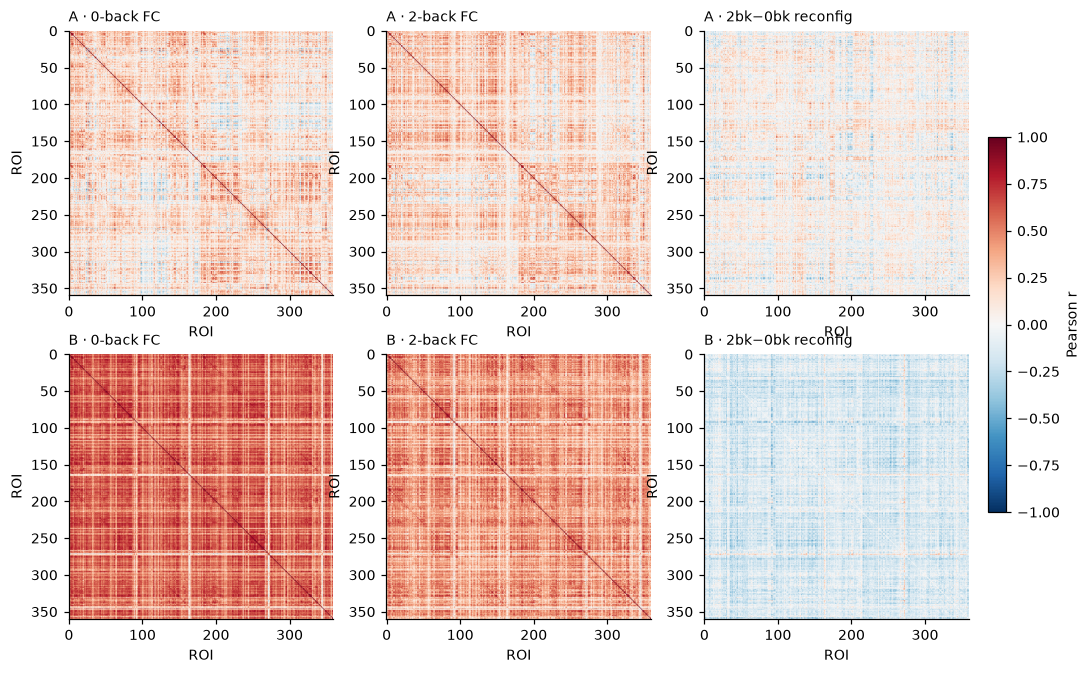

Illustrative single subjects (by position, IDs not shown); FC/graph/prediction are downstream team steps.


In [5]:
def example_fc(spec, idx=0):
    subj = ds.load_subjects(spec)[idx]                         # position, not identity
    m0 = pp.condition_timeseries(spec, subj, "0back")
    m2 = pp.condition_timeseries(spec, subj, "2back")
    return np.corrcoef(m0), np.corrcoef(m2)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for row, (spec, tag, col) in enumerate([(A, "A", C_A), (B, "B", C_B)]):
    fc0, fc2 = example_fc(spec)
    for ax, M, title in zip(axes[row], [fc0, fc2, fc2 - fc0],
                            [f"{tag} · 0-back FC", f"{tag} · 2-back FC", f"{tag} · 2bk−0bk reconfig"]):
        im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_title(title, fontsize=9, loc="left"); ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Pearson r")
plt.show()
print("Illustrative single subjects (by position, IDs not shown); FC/graph/prediction are downstream team steps.")

## 5 · What only B adds — resting-state (optional extension)

B ships **4 resting-state runs/subject** (`360 × 1200`), absent in A. This enables an *intrinsic-organization*
arm (abstract objective 2) **if** the team wants it — but it is an **extension, not the WM MVP**, which needs
only the task 0/2-back contrast.

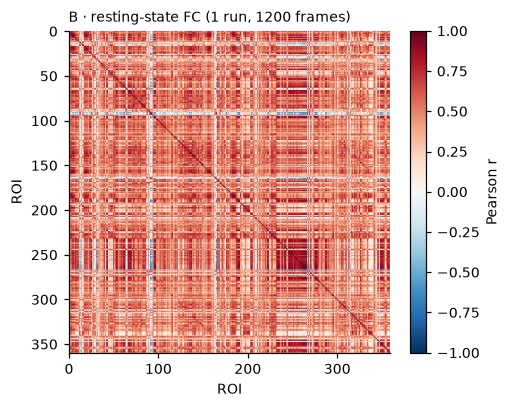

B rest: 4 runs/subject at (360, 1200). Optional extension, out of the WM MVP scope.


In [6]:
subj = ds.load_subjects(B)[0]
rest_files = sorted((B.rest_dir / "subjects" / subj / "timeseries").glob("bold*.npy"))
rest = np.load(rest_files[0])
fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(np.corrcoef(rest), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_title(f"B · resting-state FC (1 run, {rest.shape[1]} frames)", fontsize=9, loc="left")
ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
fig.colorbar(im, ax=ax, fraction=0.046, label="Pearson r"); plt.show()
print(f"B rest: {len(rest_files)} runs/subject at {rest.shape}. Optional extension, out of the WM MVP scope.")

## 6 · Decision support

| | Finalist A | Finalist B |
|---|---|---|
| Analytic subjects | 100 | **336** (339 − 3 without 2-back) |
| Signal / subject | 2 WM runs · 312 frames/load | **identical** |
| Prediction target | `acc_2bk` (0.54–0.99) | `acc_2bk` (0.41–1.00) |
| `d′` fields | inconsistent (HCP WM bug) | present in `wm.csv` (deferrable) |
| Resting-state | none | 4 runs (optional arm) |
| Subject IDs | real HCP IDs → scrub outputs | anonymized integers → safe |
| Ingestion | validated (`datasets` / `preprocessing`) | validated here, same interface |

**Reasoned recommendation (revisable):** adopt **B as the primary candidate** — 3.4× the sample at the same
signal quality and the *same interface*, with `acc_2bk` a defensible target and resting-state available if an
intrinsic-organization arm is later desired. Keep **A as a validated fallback**. The task-only MVP is
identical for both; B only widens N and adds an optional rest arm.

**Still owned by the team (not decided here):** primary target (`acc_2bk` now, `d′` derivable from B's `wm.csv`
later) · FC estimation and the evoked-response caveat · graph metrics and thresholding · association vs.
out-of-sample prediction with subject-level CV (Valeria's §9–11).

### Hand-off

With `datasets.py`, any teammate obtains per-subject/run/load matrices for **either** dataset without reading
this sandbox:

```python
import datasets as ds, preprocessing as pp
spec = ds.spec_b(DATA)                 # or ds.spec_a(DATA)
for s in ds.load_subjects(spec):
    m0 = pp.condition_timeseries(spec, s, "0back")   # 360 × 312
    m2 = pp.condition_timeseries(spec, s, "2back")   # 360 × 312
beh = pp.behaviour_table(spec)    # subject, acc_2bk, …
```

No subject IDs or per-subject derived files are committed. Open methodological decisions are listed in §6, not hidden.